# ADS1001 Member 3 Notebook: Outdoor Comfort Indicators

## Role in Group Project

**Member 3 responsibility:** Analyse outdoor comfort indicators for the public weather communication project.

This section is designed to fit directly into the group notebook after Member 2's **Dataset Overview and Data Cleaning** section. It uses the cleaned dataset prepared by Member 2 and focuses on two comfort-related research questions:

1. **Does wind chill provide additional public communication value beyond temperature in Malaysia's tropical climate?**
2. **How are humidity and dew point related, and which indicator is clearer for communicating uncomfortable or oppressive weather?**

## Connection to Main Project Question

The overall project asks:

> **Which weather indicators are most useful for communicating outdoor comfort, rainfall conditions, wind-related risk, and UV exposure to the Malaysian public?**

Member 3 contributes by evaluating whether the public weather service should prioritise **temperature and humidity**, or whether more technical indicators such as **wind chill and dew point** provide additional value for public communication.

## 1. Setup and Data Loading

This notebook uses the cleaned dataset from Member 2. The file path is written as a relative path so that the notebook can be integrated into the group project folder without relying on one person's local computer path.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATHS = [
    Path("data/malaysia_weather_cleaned_final.csv"),
    Path("malaysia_weather_cleaned_final.csv")
]

for path in DATA_PATHS:
    if path.exists():
        DATA_PATH = path
        break
else:
    raise FileNotFoundError(
        "Could not find malaysia_weather_cleaned_final.csv. "
        "Place the cleaned dataset in the same folder as this notebook or in a data/ folder."
    )

weather = pd.read_csv(DATA_PATH)
weather["datetime"] = pd.to_datetime(weather["datetime"], errors="coerce")

print("Loaded dataset from:", DATA_PATH)
print("Shape:", weather.shape)
display(weather.head())

Loaded dataset from: malaysia_weather_cleaned_final.csv
Shape: (51693, 38)


,place,city,state,temperature,pressure,dew_point,humidity,wind_speed,gust,wind_chill,uv_index,precipitation_rate,precipitation_total,year,month,day,hour,minutes,seconds,temperature_was_imputed,pressure_was_imputed,dew_point_was_imputed,humidity_was_imputed,wind_speed_was_imputed,gust_was_imputed,wind_chill_was_imputed,uv_index_was_imputed,precipitation_rate_was_imputed,precipitation_total_was_imputed,month_number,datetime,temperature_difference,gust_difference,rain_event,pressure_change,falling_pressure,uv_category,high_uv
0,Air Itam,Timur Laut,Pulau Pinang,19.4,1010.33,8.9,50.8,0.0,0.0,19.4,0.0,0.0,34.29,2019,Dec,26,17,49,49,False,False,False,False,False,False,False,False,False,False,12,2019-12-26 17:49:49,0.0,0.0,True,NaN,False,Low,False
1,Air Itam,Timur Laut,Pulau Pinang,19.4,1011.01,11.6,60.5,0.0,0.0,19.4,0.0,0.0,34.29,2019,Dec,26,19,39,58,False,False,False,False,False,False,False,False,False,False,12,2019-12-26 19:39:58,0.0,0.0,True,0.68,False,Low,False
2,Air Itam,Timur Laut,Pulau Pinang,19.4,1011.51,11.3,59.3,0.0,0.0,19.4,0.0,0.0,34.29,2019,Dec,26,20,29,50,False,False,False,False,False,False,False,False,False,False,12,2019-12-26 20:29:50,0.0,0.0,True,0.50,False,Low,False
3,Air Itam,Timur Laut,Pulau Pinang,19.6,1011.85,12.0,61.3,0.0,0.0,19.6,0.0,0.0,34.29,2019,Dec,26,20,49,50,False,False,False,False,False,False,False,False,False,False,12,2019-12-26 20:49:50,0.0,0.0,True,0.34,False,Low,False
4,Air Itam,Timur Laut,Pulau Pinang,19.3,1012.70,10.4,56.5,0.0,0.0,19.3,0.0,0.0,0.00,2019,Dec,27,0,54,48,False,False,False,False,False,False,False,False,False,False,12,2019-12-27 00:54:48,0.0,0.0,False,0.85,False,Low,False


In [2]:
# Check required variables for Member 3 analysis
required_columns = [
    "temperature", "wind_chill", "humidity", "dew_point",
    "temperature_was_imputed", "wind_chill_was_imputed",
    "humidity_was_imputed", "dew_point_was_imputed",
    "state", "city", "month_number", "hour", "datetime"
]

missing_required = [col for col in required_columns if col not in weather.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

print("All required columns for Member 3 analysis are available.")

All required columns for Member 3 analysis are available.


## 2. Member 3 Analysis Plan

Member 3 focuses on **outdoor comfort communication**. The analysis uses two pairs of related indicators:

| Comfort topic | Indicators compared | Main purpose |
|---|---|---|
| Thermal comfort | Temperature vs wind chill | Test whether wind chill adds useful information beyond temperature |
| Moisture / oppressive weather | Humidity vs dew point | Compare a familiar public indicator with a more technical moisture indicator |

The purpose is not only to check whether variables are statistically related, but to judge whether each indicator is **useful, understandable, and actionable** for public weather communication.

## 3. Data Quality Check for Comfort Variables

Before analysing the comfort indicators, we check whether the variables used in this section are complete in the cleaned dataset and how much of each variable was originally imputed during Member 2's cleaning process.

This is important because a variable with many imputed values should be interpreted more carefully.

In [3]:
comfort_cols = ["temperature", "wind_chill", "humidity", "dew_point"]

comfort_missing = pd.DataFrame({
    "missing_count_after_cleaning": weather[comfort_cols].isna().sum(),
    "missing_percentage_after_cleaning": weather[comfort_cols].isna().mean() * 100
})

display(comfort_missing)

,missing_count_after_cleaning,missing_percentage_after_cleaning
temperature,0,0.0
wind_chill,0,0.0
humidity,0,0.0
dew_point,0,0.0


In [4]:
imputation_cols = [
    "temperature_was_imputed", "wind_chill_was_imputed",
    "humidity_was_imputed", "dew_point_was_imputed"
]

imputation_summary = pd.DataFrame({
    "variable": comfort_cols,
    "imputed_count": [weather[col].sum() for col in imputation_cols],
    "imputed_percentage": [weather[col].mean() * 100 for col in imputation_cols]
})

display(imputation_summary)

,variable,imputed_count,imputed_percentage
0,temperature,4330,8.376376
1,wind_chill,4368,8.449887
2,humidity,4323,8.362834
3,dew_point,4728,9.146306


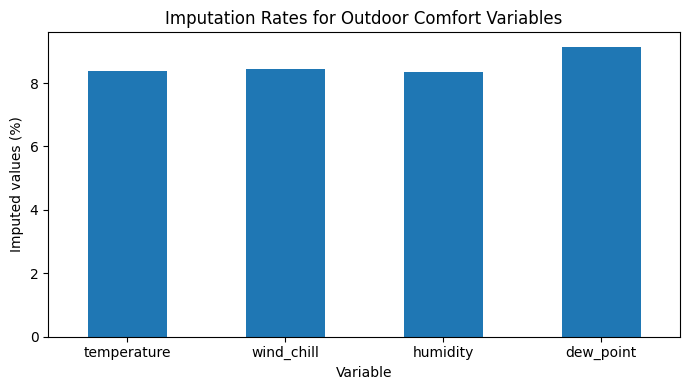

In [5]:
# Plot imputation percentages for comfort variables
imputation_summary.set_index("variable")["imputed_percentage"].plot(kind="bar", figsize=(7, 4))
plt.title("Imputation Rates for Outdoor Comfort Variables")
plt.xlabel("Variable")
plt.ylabel("Imputed values (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Short Conclusion: Data Quality for Comfort Variables

The cleaned dataset contains no missing values for the four comfort indicators used in this section. However, some values were imputed during cleaning. This means the analysis is suitable for exploring broad patterns, but the results should be interpreted carefully, especially when discussing exact distributions or public thresholds.

## 4. Research Question 1: Temperature and Wind Chill

### Research Question

> **Does wind chill provide additional public communication value beyond temperature in Malaysia's tropical climate?**

### Why this matters to the client

A public weather service should avoid overwhelming the public with indicators that communicate almost the same information. If wind chill is nearly identical to temperature in this dataset, temperature may be enough as the main public-facing comfort indicator.

In [6]:
# Clean subset for temperature and wind chill
temp_chill = weather[[
    "temperature", "wind_chill", "temperature_difference",
    "temperature_was_imputed", "wind_chill_was_imputed",
    "state", "city", "month_number", "hour"
]].dropna(subset=["temperature", "wind_chill"]).copy()

# If temperature_difference is not present for any reason, recreate it
if "temperature_difference" not in temp_chill.columns or temp_chill["temperature_difference"].isna().all():
    temp_chill["temperature_difference"] = temp_chill["temperature"] - temp_chill["wind_chill"]

display(temp_chill[["temperature", "wind_chill", "temperature_difference"]].describe())

,temperature,wind_chill,temperature_difference
count,51693.000000,51693.000000,51693.000000
mean,28.013987,28.011882,0.002106
std,3.098607,3.096055,0.105500
min,17.800000,17.800000,-3.500000
25%,25.600000,25.600000,0.000000
50%,27.300000,27.300000,0.000000
75%,30.300000,30.300000,0.000000
max,41.000000,41.000000,11.200000


In [7]:
temp_chill_corr = temp_chill["temperature"].corr(temp_chill["wind_chill"])
print("Correlation between temperature and wind chill:", round(temp_chill_corr, 4))

difference_summary = pd.DataFrame({
    "metric": [
        "Mean absolute difference",
        "Median absolute difference",
        "Maximum absolute difference",
        "Percentage with absolute difference <= 0.5°C",
        "Percentage with absolute difference <= 1.0°C"
    ],
    "value": [
        temp_chill["temperature_difference"].abs().mean(),
        temp_chill["temperature_difference"].abs().median(),
        temp_chill["temperature_difference"].abs().max(),
        (temp_chill["temperature_difference"].abs() <= 0.5).mean() * 100,
        (temp_chill["temperature_difference"].abs() <= 1.0).mean() * 100
    ]
})

display(difference_summary)

Correlation between temperature and wind chill: 0.9994


,metric,value
0,Mean absolute difference,0.002651
1,Median absolute difference,0.000000
2,Maximum absolute difference,11.200000
3,Percentage with absolute difference <= 0.5°C,99.926489
4,Percentage with absolute difference <= 1.0°C,99.934227


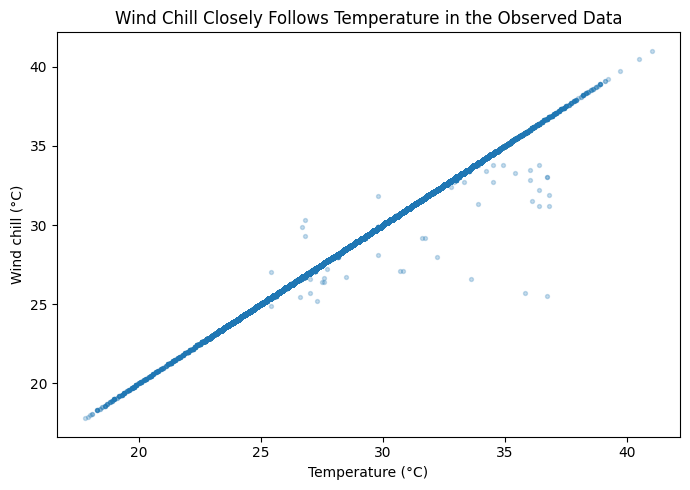

In [8]:
plt.figure(figsize=(7, 5))
plt.scatter(temp_chill["temperature"], temp_chill["wind_chill"], alpha=0.25, s=8)
plt.title("Wind Chill Closely Follows Temperature in the Observed Data")
plt.xlabel("Temperature (°C)")
plt.ylabel("Wind chill (°C)")
plt.tight_layout()
plt.show()

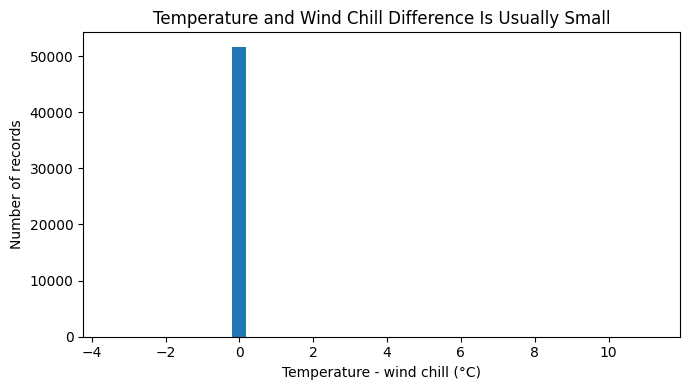

In [9]:
plt.figure(figsize=(7, 4))
plt.hist(temp_chill["temperature_difference"], bins=40)
plt.title("Temperature and Wind Chill Difference Is Usually Small")
plt.xlabel("Temperature - wind chill (°C)")
plt.ylabel("Number of records")
plt.tight_layout()
plt.show()

In [10]:
# Check whether wind chill difference varies by month
monthly_temp_chill = temp_chill.groupby("month_number").agg(
    avg_temperature=("temperature", "mean"),
    avg_wind_chill=("wind_chill", "mean"),
    avg_abs_difference=("temperature_difference", lambda x: x.abs().mean()),
    records=("temperature", "size")
).reset_index()

display(monthly_temp_chill)

,month_number,avg_temperature,avg_wind_chill,avg_abs_difference,records
0,1,27.392680,27.390952,0.001728,4515
1,2,27.757429,27.752378,0.005051,3890
2,3,28.451584,28.435310,0.017416,4292
3,4,28.568179,28.565219,0.006203,4409
4,5,28.855057,28.854972,0.000085,4706
5,6,28.268469,28.268469,0.000000,4716
6,7,28.287488,28.287488,0.000000,5239
7,8,27.985116,27.985116,0.000000,5160
8,9,27.715478,27.715478,0.000000,3253
9,10,27.798596,27.798596,0.000000,3667


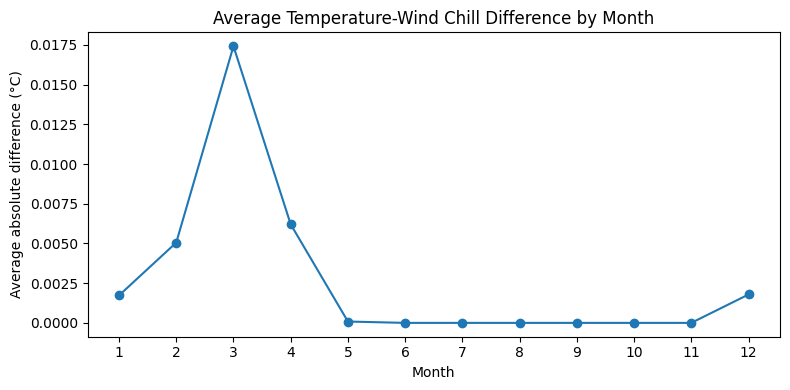

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(monthly_temp_chill["month_number"], monthly_temp_chill["avg_abs_difference"], marker="o")
plt.title("Average Temperature-Wind Chill Difference by Month")
plt.xlabel("Month")
plt.ylabel("Average absolute difference (°C)")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

### Interpretation: Temperature and Wind Chill

The analysis compares temperature and wind chill directly. If the correlation is very high and the difference between them is usually small, wind chill provides limited extra information beyond temperature.

For public communication in Malaysia's tropical context, this suggests that **temperature is likely clearer and more useful as the main thermal comfort indicator**. Wind chill may be kept as a supporting indicator, but it does not need to be highlighted unless it differs meaningfully from temperature.

### Short Conclusion: Temperature and Wind Chill

Temperature and wind chill are strongly related in the cleaned dataset, and their differences are usually small. For the client, this means **temperature should be prioritised as the main public-facing comfort indicator**, while wind chill can be de-emphasised in routine Malaysian weather communication.

## 5. Research Question 2: Humidity and Dew Point

### Research Question

> **How are humidity and dew point related, and which indicator is clearer for communicating uncomfortable or oppressive weather?**

### Why this matters to the client

Humidity is familiar to the public because it is usually expressed as a percentage. Dew point is more technical, but it can provide useful context for moisture and muggy conditions. This analysis helps decide whether humidity alone is enough for public messaging or whether dew point should be included as supporting information.

In [12]:
# Clean subset for humidity and dew point
moisture = weather[[
    "humidity", "dew_point", "humidity_was_imputed", "dew_point_was_imputed",
    "state", "city", "month_number", "hour"
]].dropna(subset=["humidity", "dew_point"]).copy()

display(moisture[["humidity", "dew_point"]].describe())

,humidity,dew_point
count,51693.000000,51693.000000
mean,82.022445,24.300320
std,13.401809,1.848328
min,0.000000,7.700000
25%,72.800000,23.400000
50%,84.400000,24.200000
75%,93.000000,25.000000
max,100.000000,32.200000


In [13]:
humidity_dew_corr = moisture["humidity"].corr(moisture["dew_point"])
print("Correlation between humidity and dew point:", round(humidity_dew_corr, 4))

# Identify unusual humidity values
humidity_zero_count = (moisture["humidity"] == 0).sum()
humidity_zero_percentage = (moisture["humidity"] == 0).mean() * 100

print("Rows with humidity equal to 0:", humidity_zero_count)
print("Percentage of rows with humidity equal to 0:", round(humidity_zero_percentage, 3), "%")

Correlation between humidity and dew point: 0.2842
Rows with humidity equal to 0: 27
Percentage of rows with humidity equal to 0: 0.052 %


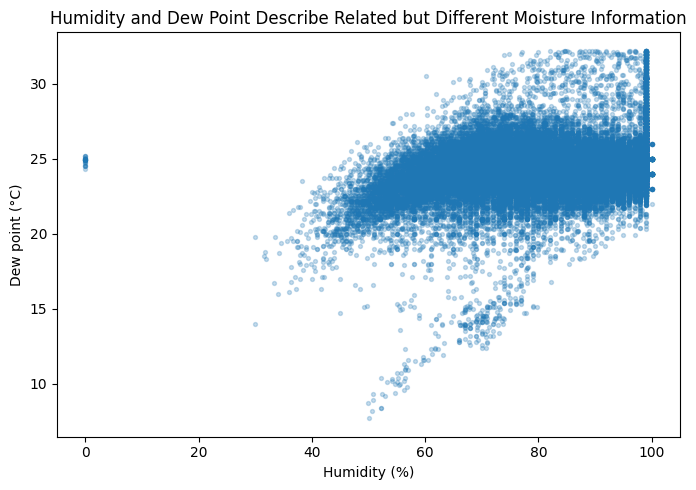

In [14]:
plt.figure(figsize=(7, 5))
plt.scatter(moisture["humidity"], moisture["dew_point"], alpha=0.25, s=8)
plt.title("Humidity and Dew Point Describe Related but Different Moisture Information")
plt.xlabel("Humidity (%)")
plt.ylabel("Dew point (°C)")
plt.tight_layout()
plt.show()

In [15]:
# Sensitivity check excluding humidity = 0, because it may be unusual in this climate context
moisture_no_zero = moisture[moisture["humidity"] > 0].copy()

humidity_dew_corr_no_zero = moisture_no_zero["humidity"].corr(moisture_no_zero["dew_point"])
print("Correlation excluding humidity = 0:", round(humidity_dew_corr_no_zero, 4))
print("Rows remaining after excluding humidity = 0:", len(moisture_no_zero))

Correlation excluding humidity = 0: 0.2881
Rows remaining after excluding humidity = 0: 51666


In [16]:
# Data-driven high moisture indicators using upper quartile values
humidity_q3 = moisture_no_zero["humidity"].quantile(0.75)
dew_point_q3 = moisture_no_zero["dew_point"].quantile(0.75)

moisture_no_zero["high_humidity_dataset_based"] = moisture_no_zero["humidity"] >= humidity_q3
moisture_no_zero["high_dew_point_dataset_based"] = moisture_no_zero["dew_point"] >= dew_point_q3

comfort_flag_summary = pd.DataFrame({
    "indicator": [
        "Humidity upper quartile threshold",
        "Dew point upper quartile threshold",
        "High humidity share",
        "High dew point share",
        "Both high humidity and high dew point share"
    ],
    "value": [
        humidity_q3,
        dew_point_q3,
        moisture_no_zero["high_humidity_dataset_based"].mean() * 100,
        moisture_no_zero["high_dew_point_dataset_based"].mean() * 100,
        (moisture_no_zero["high_humidity_dataset_based"] & moisture_no_zero["high_dew_point_dataset_based"]).mean() * 100
    ]
})

display(comfort_flag_summary)

,indicator,value
0,Humidity upper quartile threshold,93.000000
1,Dew point upper quartile threshold,25.000000
2,High humidity share,26.384857
3,High dew point share,29.446832
4,Both high humidity and high dew point share,9.412380


In [17]:
# Monthly averages for humidity and dew point
monthly_moisture = moisture_no_zero.groupby("month_number").agg(
    avg_humidity=("humidity", "mean"),
    avg_dew_point=("dew_point", "mean"),
    records=("humidity", "size")
).reset_index()

display(monthly_moisture)

,month_number,avg_humidity,avg_dew_point,records
0,1,81.451916,23.518682,4515
1,2,79.573265,23.437905,3890
2,3,80.081337,24.213607,4292
3,4,82.359061,24.903277,4409
4,5,80.870656,24.892819,4679
5,6,81.578594,24.499767,4716
6,7,81.899819,24.595362,5239
7,8,82.789428,24.492306,5160
8,9,82.825761,24.145835,3253
9,10,83.184047,24.288915,3667


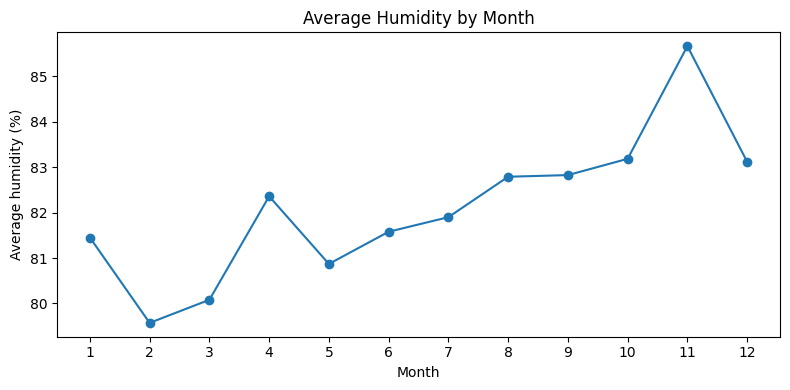

In [18]:
plt.figure(figsize=(8, 4))
plt.plot(monthly_moisture["month_number"], monthly_moisture["avg_humidity"], marker="o")
plt.title("Average Humidity by Month")
plt.xlabel("Month")
plt.ylabel("Average humidity (%)")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

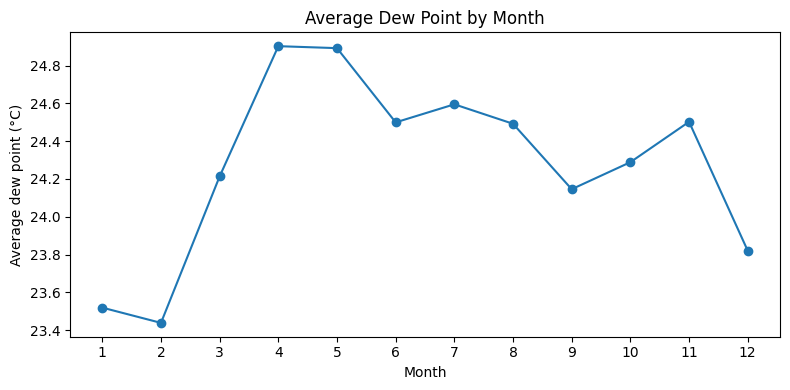

In [19]:
plt.figure(figsize=(8, 4))
plt.plot(monthly_moisture["month_number"], monthly_moisture["avg_dew_point"], marker="o")
plt.title("Average Dew Point by Month")
plt.xlabel("Month")
plt.ylabel("Average dew point (°C)")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

### Interpretation: Humidity and Dew Point

Humidity and dew point both describe moisture-related comfort, but they serve different communication purposes.

- **Humidity** is easier for the general public to understand because it is expressed as a percentage.
- **Dew point** may provide useful supporting context for muggy or oppressive conditions, but it is less familiar and may require explanation.

For the client, this means humidity should be the main public-facing moisture indicator, while dew point can be used as supporting information in more detailed comfort messages.

### Short Conclusion: Humidity and Dew Point

Humidity and dew point are related but not identical. For public communication, **humidity should be prioritised because it is easier to understand**, while dew point can support technical interpretation of uncomfortable or oppressive weather.

## 6. Member 3 Recommendation Table

The table below summarises the final recommendation from Member 3's analysis for the public weather information service.

In [20]:
member3_recommendations = pd.DataFrame({
    "Indicator": ["Temperature", "Wind chill", "Humidity", "Dew point"],
    "Public communication value": ["High", "Low / Medium", "High", "Medium"],
    "Reason": [
        "Familiar, easy to understand, and suitable as the main thermal comfort indicator.",
        "Usually closely follows temperature, so it adds limited extra value in routine tropical communication.",
        "Familiar percentage-based indicator for moisture and comfort messages.",
        "Useful supporting technical indicator, but less familiar to the public."
    ],
    "Recommendation": [
        "Use as the main public-facing comfort indicator.",
        "Use only as supporting information when it differs meaningfully from temperature.",
        "Use as the main public-facing moisture comfort indicator.",
        "Use as supporting context for muggy or oppressive conditions."
    ]
})

display(member3_recommendations)

,Indicator,Public communication value,Reason,Recommendation
0,Temperature,High,"Familiar, easy to understand, and suitable as ...",Use as the main public-facing comfort indicator.
1,Wind chill,Low / Medium,"Usually closely follows temperature, so it add...",Use only as supporting information when it dif...
2,Humidity,High,Familiar percentage-based indicator for moistu...,Use as the main public-facing moisture comfort...
3,Dew point,Medium,"Useful supporting technical indicator, but les...",Use as supporting context for muggy or oppress...


## 7. Handoff Notes for Group Integration

### For Presentation Slides

Member 3 should use two main slides:

1. **Slide 5: Temperature vs Wind Chill**
   - Suggested figure: scatter plot of temperature vs wind chill.
   - Suggested title: *Wind Chill Closely Follows Temperature in the Observed Data.*
   - Key message: temperature is enough as the main thermal comfort indicator.

2. **Slide 6: Humidity vs Dew Point**
   - Suggested figure: scatter plot of humidity vs dew point, or monthly humidity/dew point patterns.
   - Suggested title: *Humidity and Dew Point Describe Related but Different Moisture Information.*
   - Key message: humidity is clearer for public communication, while dew point is supporting context.

### For Poster

Use one or two of the clearest figures:
- Temperature vs wind chill scatter plot.
- Humidity vs dew point scatter plot.
- Member 3 recommendation table.

### For Overall Group Conclusion

Member 3's final contribution is:

> For outdoor comfort communication, the public weather service should prioritise **temperature and humidity** because they are familiar and easy to understand. **Wind chill and dew point** can still be useful, but they should be treated as supporting or technical indicators rather than the main public-facing indicators.

## 8. Final Short Conclusion for Member 3

This analysis supports the overall project aim by identifying which comfort indicators are most useful for public communication. Temperature and humidity are the strongest public-facing indicators because they are familiar, understandable, and directly relevant to outdoor comfort. Wind chill and dew point provide additional context, but they are better used as supporting indicators.

These conclusions can be integrated into the final group recommendation table and used to support the client-facing presentation and poster.